### Spontaneous activity: lfp example + cfc metrics


1. Load in segments of neural recordings where no vocalizations were taking place and no playback was given ("spontaneous activity"). We had searched through the data for time windows in which at least 60 seconds of nothing was happening. 

2. Cross-frequency coupling (low-frequency power : high-frequency amplitude)


In [1]:
import sys, importlib, os
sys.path.append('./../') # rel. dir. to find ephystoolbox 
from glob import glob 
# my functions
from ephystoolbox import unpack, preprocess, process, utils

# basics
import random
import copy
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

# signal processing and statistics
from scipy import signal, io, fft, stats
import statsmodels.api as sm
from statsmodels.stats import multitest

# plotting
import seaborn as sns
from matplotlib import colors
import matplotlib.pyplot as plt
from matplotlib import rc
rc("pdf", fonttype=42)

/mnt/hpc/projects/BWFAFdeactivNpx/_frontal_vocal_paper_repo/code/neural_analysis/ephystoolbox/process.py:3: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof.utils import interpolate_spectrum


In [90]:
# use when plotting scalar values, i.e. you want 1 color to represent the conditions control and muscimol
pal = [plt.cm.viridis(np.linspace(0.4,0.6,1)),
       plt.cm.magma(np.linspace(0.4,0.6,1))]
pald = {'control':plt.cm.viridis(np.linspace(0.4,0.6,1)),
       'muscimol': plt.cm.magma(np.linspace(0.4,0.6,1))}

# use when variable # of colors wanted from treatment palette
def colormap(treatment, n=16):
    if treatment=="control":        
        cmap = plt.cm.viridis(np.linspace(0.4,0.9,n))    
        if n==1:
            cmap = plt.cm.viridis(np.linspace(0.4,0.6,1))    
    elif treatment=="muscimol":
        cmap = plt.cm.magma(np.linspace(0.4,0.9,n))
        if n==1:
            cmap = plt.cm.magma(np.linspace(0.4,0.6,1))            
    return(cmap)

In [2]:
# processed data directories
d1_dir = './../../neural_data/LFP_spontaneous/raw_segments'
# results directory
# r1_dir = './'


In [3]:
# parameters
Fs = 1e4
channel_depths = np.arange(50,850,50) #@updated to true depth as of 20240510

### Wrangle data segments

In [4]:
seg_data = {} 
for f in glob(d1_dir+"/*.npy"):
    print(f)
    
    fdata = {'anim#': f.rsplit('\\')[-1].rsplit('_')[2], 'contrast': f.rsplit('\\')[-1].rsplit('_')[4]}
    loaded_seg_dict = np.load(f,allow_pickle=True).all()    
    relist = [v for v in loaded_seg_dict.values()]

    if fdata['anim#'] not in seg_data.keys():
        seg_data[fdata['anim#']] = {}
        
    if fdata['contrast'] == "pre":
        seg_data[fdata['anim#']]['control'] = relist #.update({'control':relist})
    elif fdata['contrast'] == "post":
        seg_data[fdata['anim#']]['muscimol'] = relist #.update({'muscimol':relist})
    

In [6]:
# if you go back to save the start/stop times for segments saved to above data, then you could just 
# filter relative spike times for any spikes falling in that period... 

# spiking_data_files = glob(data_dir+'/*/*_spikes.npy')
# rel_spiking_file = spiking_data_files[int(np.argwhere([f.rsplit('_LFP')[0] + '_spikes.npy' == spikes_file.rsplit('\\')[-1] for spikes_file in spiking_data_files]))]
# spike_dat = np.load(rel_spiking_file, allow_pickle=True).all()
# spike_dat[4]/1e4

In [94]:
query_durs = True
if query_durs:
    for anim in seg_data.keys():
        print(anim)
        for treat in seg_data[anim].keys():
            print(treat + ': ' + str(len(seg_data[anim][treat])))
            l = 0
            ll = []
            for s in range(len(seg_data[anim][treat])):
                l=l+seg_data[anim][treat][s].shape[-1]/Fs
                ll.append(seg_data[anim][treat][s].shape[-1]/Fs)

            print(l)
            print(np.max(ll))

F1
muscimol: 1
156.9162
156.9162
control: 1
287.5848
287.5848
F2
muscimol: 2
131.69240000000002
66.1293
F3
muscimol: 5
596.5197
193.5045
control: 8
745.8159
148.7721
F4
muscimol: 5
452.77790000000005
120.9882
control: 6
603.3405
135.7345
M2
muscimol: 16
23358.400000000005
1459.9
M3
muscimol: 6
812.929
214.8736
control: 9
669.8752999999999
101.5245
M4
muscimol: 7
522.3238
85.1736
control: 1
134.2873
134.2873


In [ ]:
sel_from_all = True
sel_from_longest = False
sel_longest = False

# segment length
d = int(Fs*10) 
# n desired samples from each segment        
k = 5

sliced_seg_data = {}
#print(sliced_seg_data)
for anim in seg_data.keys():
    print(anim)
    if anim=="M2" or anim=="F2": # no pre, so inadequate for comp.
        continue
        
    sliced_seg_data[anim] = {}
    
    for treatment in seg_data[anim].keys():
        print(treatment)
        
        sliced_seg_data[anim][treatment] = {}
        sliced_data = [] # collect from all segments - alternatively, you could add bits from each segment separately...
        # get seg lengths in samples
        seg_lens = [s.shape[-1] for s in seg_data[anim][treatment]]
        
        # select longest segment?
        if sel_from_longest:
            sel_seg = seg_data[anim][treatment][np.argmax(seg_lens)]
            N = sel_seg.shape[-1] # range
        
            if sel_longest: # take longest segment
                d = N
            # otherwise, just select a segment of previously requested length d from the longest segment
            starts_sp = np.sort(np.array(utils.sample_with_minimum_distance(n=N-(d-1), k=k,d=d)))
            sub_segs_sp = np.vstack(((starts_sp),(starts_sp+d))).T
            
            # segment data actually
            for m in range(len(sub_segs_sp)):
                sliced_data.append(sel_seg[:,sub_segs_sp[m,0]:sub_segs_sp[m,1]]) 
            print(sliced_data[0].shape[-1]/Fs)

        if sel_from_all: # take segments of a particular length from all segments 
            for s in range(len(seg_data[anim][treatment])):
                print('dur (s): '+ str(np.round(seg_data[anim][treatment][s].shape[1]/Fs)))
                N = seg_data[anim][treatment][s].shape[1] # range
                starts_sp = np.sort(np.array(utils.sample_with_minimum_distance(n=N-(d-1), k=k,d=d)))
                sub_segs_sp = np.vstack(((starts_sp),(starts_sp+d))).T

                print('n segs: ' + str(len(sub_segs_sp)))
                # segment data actually
                for m in range(len(sub_segs_sp)):
                    sliced_data.append(seg_data[anim][treatment][s][:,sub_segs_sp[m,0]:sub_segs_sp[m,1]])   
                
        sliced_seg_data[anim][treatment] = sliced_data
sliced_seg_data

F1
muscimol
156.9162
control
287.5848
F2
F3
muscimol
193.5045
control
148.7721
F4
muscimol
120.9882
control
135.7345
M2
M3
muscimol
214.8736
control
101.5245
M4
muscimol
85.1736
control
134.2873


{'F1': {'muscimol': [array([[ -11.83931419,  -10.91384136,   -9.86293051, ...,   -1.80583126,
             -2.6806402 ,   -3.4902732 ],
          [ -12.87617963,  -12.33794316,  -11.65000686, ...,   -3.0443852 ,
             -4.14087002,   -5.17097387],
          [ -11.14570151,  -10.3031076 ,   -9.33259636, ...,   -1.42121738,
             -2.34728043,   -3.20633625],
          ...,
          [-139.79195412, -144.0106534 , -147.88690295, ..., -131.87923431,
           -127.00071776, -121.89561915],
          [          nan,           nan,           nan, ...,           nan,
                     nan,           nan],
          [-135.34513726, -139.43916819, -143.94634736, ..., -117.02934194,
           -115.42441075, -113.72352886]])],
  'control': [array([[  16.30715735,   18.19318663,   19.96826599, ...,   -5.50818137,
             -3.92230092,   -2.43120667],
          [  17.4884726 ,   19.2000669 ,   20.78093481, ...,   -3.99103852,
             -2.52778514,   -1.1570449 ],
         

Select N samples from each animal x treatment

In [ ]:
minN = 5
samp_seg_data = {}
for anim in sliced_seg_data.keys():
    print(anim)
    samp_seg_data[anim] = {}
    for treat in sliced_seg_data[anim].keys():
        print(len(sliced_seg_data[anim][treat]))
        slice_at = np.array(random.sample(range(len(sliced_seg_data[anim][treat])),minN))
        subsect_slices = np.array(sliced_seg_data[anim][treat])[slice_at]
        samp_seg_data[anim][treat] = subsect_slices # slice x ch x timeseries


F1
1
1
F3
1
1
F4
1
1
M3
1
1
M4
1
1


Z-score LFPs within animals, across treatments

In [ ]:
z_norm = True
samp_seg_data2 = {} 
for anim in samp_seg_data.keys():
    print(anim)
    samp_seg_data2[anim] = {}
    
    catch_for_norm = []
    for treat in samp_seg_data[anim].keys():
#         print(len(samp_seg_data[anim][treat]))
        catch_for_norm.append(samp_seg_data[anim][treat])
        # np.vstack((catch_for_norm))
    
    anim_segs = np.vstack((catch_for_norm))
    # reshape by collapsing trial (sequence) and channel data to z-score along timepoints
    segs_flat = anim_segs.reshape(1,anim_segs.shape[0]*anim_segs.shape[1]*anim_segs.shape[2])
    if z_norm:
        z_vec = stats.zscore(segs_flat,axis=1,nan_policy='omit')
    else:
        z_vec = segs_flat
    anim_segs_z = z_vec.reshape(anim_segs.shape[0],anim_segs.shape[1],anim_segs.shape[2])
    
    reslice_int = np.vstack((np.arange(0,anim_segs.shape[0],minN), np.arange(0,anim_segs.shape[0],minN)+minN))
    
    for treatN in range(len(samp_seg_data[anim].keys())):
        treats = list(samp_seg_data[anim].keys())
        samp_seg_data2[anim][treats[treatN]] = anim_segs_z[reslice_int[treatN][0]:reslice_int[treatN][1],:,:]
        print(samp_seg_data2[anim][treats[treatN]].shape)


#### Plot examples

The below is computed after taking the longest segment available for each animal and plotting that for an exemplary animal, F4.

In [96]:
## REQUIRES the following settings, recompute above. Don't use z-normed. 
sel_from_all = False
sel_from_longest = True
sel_longest = True

# segment length
d = int(Fs*10) 
# n desired samples from each segment        
k = 1 

minN = 1

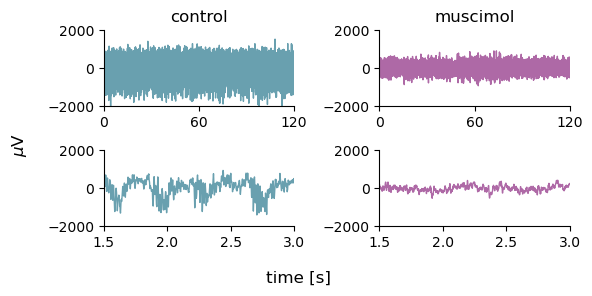

In [105]:

t = np.arange(0,59*Fs)/Fs

fig,ax=plt.subplots(2,2,figsize=(6,3))
anim = 'F4'
seg = 0
ch = 0
a = 0
t1 = 0
t2 = 120
t12 = 1.5
t22 = 3
for treat in ['control','muscimol']:
    t = np.arange(0,samp_seg_data[anim][treat][seg].shape[-1])/Fs
    ax[0,a].plot(t,samp_seg_data[anim][treat][seg][ch],alpha=0.7,linewidth=1,c=colormap(treat,1))
    ax[0,a].set_xlim(t1,t2)
    ax[0,a].set_xticks(np.linspace(t1,t2,3))
    ax[0,a].set_title(treat)
    ax[1,a].plot(t,samp_seg_data[anim][treat][seg][ch],alpha=0.7,linewidth=1,c=colormap(treat,1))
    ax[1,a].set_xlim(t12,t22)
    a+=1

for a in ax.flat:
#     a.set_xlim(0,120)
    # a.label_outer()
    a.set_xlabel('')
    a.set_ylim(-2e3,2e3)
    # a.set_ylabel('$\mu$v')
    a.spines[['right', 'top']].set_visible(False)

fig.supxlabel('time [s]', y=0.03)
fig.supylabel('$\mu$V')

fig.tight_layout()
# fig.savefig(os.path.join(r1_dir, 'raw_trace_'+anim+'_ch'+str(ch)+'.pdf'),bbox_inches = "tight")
fig.savefig(os.path.join(r1_dir, 'wave_1_raw_trace_'+anim+'_ch'+str(ch)+'.png'),bbox_inches = "tight") 

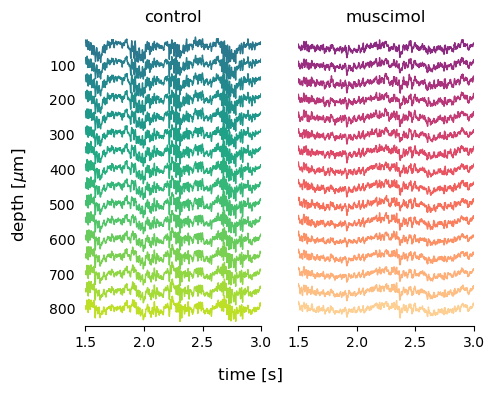

In [28]:
channel_ids = np.arange(1,17)[::-1] # for plotting
depths = np.arange(50,850,50)
fig, axs = plt.subplots(1, 2, figsize=(5,4))

ax = 0
for treat in ['control','muscimol']: # pre vs post   

    ch_dat = samp_seg_data[anim][treat][seg]
    ch_norm = ch_dat/ch_dat.max(axis=1)[:,None] # the last term transposes
    ch_plt = unpack.rescale_channels(ch_norm)
    t = np.arange(0,samp_seg_data[anim][treat][seg].shape[-1])/Fs

    # plot channels
    for i in range(ch_plt.shape[0]): # plots filled from the top of the matrix/top of the figure downwards
        axs[ax].plot(t,ch_plt[i,:].T, color=colormap(treat, n=ch_plt.shape[0])[i], linewidth=1)#[i,:]) 
        axs[ax].label_outer()

    axs[ax].set_xlim(1.5,3)  
    axs[ax].set_ylim(0,17)      
    axs[0].set_yticks(channel_ids[1:len(depths):2])
    axs[0].set_yticklabels(depths[1:len(depths):2])
    axs[ax].set_title(treat)

    axs[ax].spines[['left','right', 'top']].set_visible(False)
    axs[ax].tick_params(left=False)

    ax=+1
    fig.subplots_adjust(hspace=0.3)
    fig.supylabel('depth [$\mu$m]')
    fig.supxlabel('time [s]', y=0.03)
    fig.tight_layout()
    
    fig.savefig(os.path.join(r1_dir, 'wave_2_raw_trace_'+anim+'_channels.png'), bbox_inches = "tight") 

### Compute periodicity of rhythmic components


In [32]:
band_pltlabs = [r"$\delta$",r"$\theta$",r"$\alpha$",r"$\beta$",r"$\gamma$"]#r"${\gamma_1}$",r"${\gamma_2}$"]
band_labs = ["delta","theta","alpha","beta","gamma"] #"gamma1","gamma2"]
bands = [[1,4],[4,8],[8,12],[12,30],[30,120]]#[30,60],[60,120]]
band_filt = dict(zip(band_labs,bands))

band_cmap = dict(zip(band_labs, plt.cm.twilight_shifted(np.linspace(0.2,0.9,len(band_labs)))))
band_labeller = dict(zip(band_labs, band_pltlabs))
band_labeller

{'delta': '$\\delta$',
 'theta': '$\\theta$',
 'alpha': '$\\alpha$',
 'beta': '$\\beta$',
 'gamma': '$\\gamma$'}

Apply filters to raw LFP for each segment...

In [11]:
# compute gamma
nyq = 0.5*Fs
filt_dat = {}
dat_idx = {}
# example:
# anims = ['F4']
# s = 0 # segment
# if all:
anims = list(sliced_seg_data.keys())

# but group by treatment and channel
for treat in ['control','muscimol']: #samp_seg_data[anims[0]].keys():#samp_seg_data2

    filt_dat[treat] = {}
    # if one animal:
    # segs_allanims = np.array(samp_seg_data[anims[0]][treat][s])

    ## THIS VERSION COLLAPSES ALL DATA FROM ALL ANIMALS/SEGMENTS FOR THIS CONDITION
    # if all:
    segs_allanims = np.vstack(([sliced_seg_data[a][treat] for a in anims]))
    anim_idx = np.concatenate([np.repeat(a, len(sliced_seg_data[a][treat])) for a in anims],dtype=str)
    seg_idx = np.concatenate([np.arange(0,len(sliced_seg_data[a][treat])) for a in anims],dtype=int)
    dat_idx[treat] = {'anim': anim_idx, 'seg_n': seg_idx}
    for band in band_filt.keys():
        print(band)        
        dfilt = []

        # applies filter
        for ch in range(segs_allanims.shape[0]):
            sos = signal.butter(4, np.array([band_filt[band][0], band_filt[band][1]])/nyq, btype='band', output='sos') 
            filt_sig = signal.sosfiltfilt(sos, segs_allanims[ch,:])                    
            dfilt.append(filt_sig)
        filt_dat[treat].update({band: dfilt})


delta
theta
alpha
beta
gamma
delta
theta
alpha
beta
gamma


### Delta-theta - Gamma Coupling

Measure for all segments... 

In [ ]:
# 5 segments of 10 seconds per animal and condition, zscored
# samp_seg_data2
# N segments of 10 seconds
# sliced_seg_data

In [5]:
# parametrize for PAC
channel_depths = np.arange(50,850,50)
nyq = 0.5*Fs
# low_bands = np.vstack((np.arange(0.5,12.5,1),np.arange(1.5,13.5,1))) # start, stop
# high_bands = np.vstack((np.arange(19,80,1),np.arange(21,82,1)))
l_int = 1
h_int = 5
low_bands = np.vstack((np.arange(1,8,l_int),np.arange(3,10,l_int))) # start, stop
high_bands = np.vstack((np.arange(15,120,h_int),np.arange(25,130,h_int)))

print("Bands for phase:")
print(low_bands)
print("Bands for amplitude:")
print(high_bands)



Bands for phase:
[[1 2 3 4 5 6 7]
 [3 4 5 6 7 8 9]]
Bands for amplitude:
[[ 15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90  95 100
  105 110 115]
 [ 25  30  35  40  45  50  55  60  65  70  75  80  85  90  95 100 105 110
  115 120 125]]


In [6]:
query_ch = np.array([0])

#### Filter LFP for phase and amplitude frequencies

In [250]:
CTS_mat = {} # composite time series theta(t), Amp(t) for each f_theta and f_Amp
MI_mat = {} # absolute value of product theta(t)*Amp(t) for each f_theta and f_Amp and each value of t for N_segs x N_t
MI_trialwise = {} # absolute value product theta(t)*Amp(t) for each f_theta and f_Amp and segment for each N_segs


for anim in samp_seg_data2.keys(): # anim = 'F4'
    CTS_mat[anim] = {}
    MI_mat[anim] = {}
    MI_trialwise[anim] = {}
    for treat in samp_seg_data2[anim].keys():
        CTS_mat[anim][treat] = {}
        MI_mat[anim][treat] = {}
        MI_trialwise[anim][treat] = {}
        for ch in query_ch: #range(len(channel_depths)):
            CTS_mat[anim][treat][ch] = {'phase':{},'Amp':{}}
            MI_mat[anim][treat][ch] = {}
            MI_trialwise[anim][treat][ch] = {}

        #     for s in range(len(sliced_seg_data[anim][treat])):
        #     seg = sliced_seg_data[anim][treat][s] # rows are N_channels, N_timepoints
            seg = np.vstack(([s[ch] for s in samp_seg_data2[anim][treat]])) # rows are N_segments, N_timepoints for each channel
                    
            # compute MI for each segment x combination of frequencies
            tw_MI_matrix = np.zeros((len(low_bands[0]),len(high_bands[0]), seg.shape[0]))
            # compute average MI for all segments for this channel
            avg_MI_matrix = np.zeros((len(low_bands[0]),len(high_bands[0])))


            for i in range(len(low_bands[0])):
                #print("filtering for phase: " + str([low_bands[0][i], low_bands[1][i]]))
                sos = signal.butter(4, np.array([low_bands[0][i], low_bands[1][i]])/nyq, btype='band', output='sos') 
                filt_dat = signal.sosfiltfilt(sos, seg, axis=1) # filter each trial/row 
                # hilbert transform
                analytic_dat = signal.hilbert(filt_dat)
                # take phase phi(t) for all timepoints, t
                iphase = np.angle(analytic_dat, deg=False) 

                CTS_mat[anim][treat][ch]['phase'][low_bands[0][i]] = iphase
        
                for j in range(len(high_bands[0])):
                    #print("filtering for amp: " + str([high_bands[0][j], high_bands[1][j]]))
                    sos = signal.butter(4, np.array([high_bands[0][j], high_bands[1][j]])/nyq, btype='band', output='sos') 
                    filt_dat = signal.sosfiltfilt(sos, seg, axis=1) # filter each trial/row 
                    analytic_dat2 = signal.hilbert(filt_dat)
                    # amplitude A(t) at each timepoint, t 
                    iamplitude = np.abs(analytic_dat2) 

                    CTS_mat[anim][treat][ch]['Amp'][high_bands[0][j]] = iamplitude

                    # --- compute modulation index --- 
                    # compute composite for every combination of low frequency phase x high frequency amplitude:

                    # what you thought was right
                    # product_ts = iphase * iamplitude                    
                    # sebbe <3
                    product_ts = np.exp(iphase*1j)*iamplitude - np.mean(np.exp(iphase*1j)*iamplitude)
                    
                    # modulation index
                    trialwise_MI = np.abs(np.nanmean(product_ts,1))
                    # average over trials
                    MI = np.abs(np.nanmean(product_ts)) 

                    tw_MI_matrix[i,j,:] = trialwise_MI
                    avg_MI_matrix[i,j] = MI

            MI_mat[anim][treat][ch] = avg_MI_matrix
            MI_trialwise[anim][treat][ch] = tw_MI_matrix
            
# np.save(data_dir+'/cache_data/LFP_spontaneous/pac/MI_composite_avg',MI_mat) 
# np.save(data_dir+'/cache_data/LFP_spontaneous/pac/MI_composite_trialwise',MI_trialwise) 


##### Example

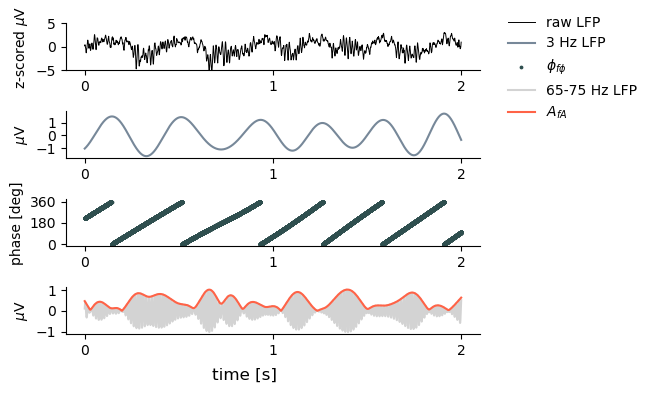

In [271]:
fig, ax = plt.subplots(4,1,figsize=(5,4))

st = 2
s = 2
t = np.arange(Fs*st,Fs*(st+s),dtype=int)#/Fs
seg = samp_seg_data2['F4']['control'][0,0,:]
# raw
ax[0].plot(t/Fs-st,seg[t], c='k', label='raw LFP',linewidth=0.7)
ax[0].set_ylim(-5,5)
# low LFP
sos = signal.butter(4, np.array([2,4])/nyq, btype='band', output='sos') 
filt_dat = signal.sosfiltfilt(sos, seg) # filter each trial/row 
ax[1].plot(t/Fs-st,filt_dat[t], c='lightslategray', label='3 Hz LFP')
# ax[1].set_ylim(-1,1.5)
# phase
analytic_dat = signal.hilbert(filt_dat)
phase_p = np.angle(analytic_dat, deg=False)
# if degrees
# phase_p_deg = phase_p + 180 # ask seb: would there be anything wrong this a straight scaling like this?
# phase_p_deg = phase_p % 360 # but both this method
# if radians
phase_p_deg = np.rad2deg((phase_p + 2 * np.pi) % (2 * np.pi)) # and this method scale so that peaks are at 0/360
ax[2].scatter(t/Fs-st,phase_p_deg[t], c='darkslategray', s=3, label='$\phi_{f\phi}$')
# ax[2].plot(t/Fs-st,phase_p_deg[t], c='darkslategray', label='_nolegend_', alpha = 0.2)
ax[2].set_yticks([0,180,360])
# high LFP and Amp
sos = signal.butter(4, np.array([65, 75])/nyq, btype='band', output='sos') 
filt_dat = signal.sosfiltfilt(sos, seg) # filter each trial/row 
analytic_dat2 = signal.hilbert(filt_dat)
amp_p = np.abs(analytic_dat2)
ax[3].plot(t/Fs-st, filt_dat[t], c='lightgray', label='65-75 Hz LFP')
ax[3].plot(t/Fs-st, amp_p[t], c='tomato', label='$A_{fA}$')
# ax[3].set_ylim(-1,1)

for a in ax:
    a.spines[['right','top']].set_visible(False)
    # a.label_outer()
    a.set_xticks([0,1,2],[0,1,2])
    a.set_ylabel('$\mu$V')
ax[0].set_ylabel('z-scored $\mu$V')
ax[2].set_ylabel('phase [deg]')
# fig.supylabel('$\mu$V', x=0.05)
fig.supxlabel('time [s]', y=0.05)

fig.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(r1_dir, 'pac_1_method.png'),bbox_inches = "tight", 
            transparent=True) 


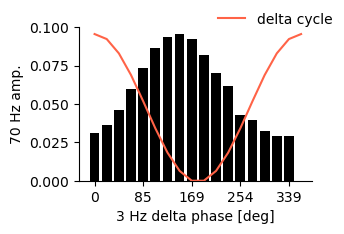

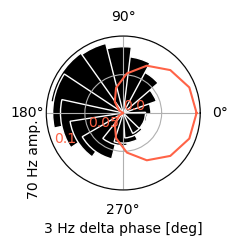

In [272]:
N = int(360/20) # number of bins
bins = np.linspace(0.0,360,int(360/20)) # 20-18 deg. bins
t = 1
c = 'control'
amp = CTS_mat['F4'][c][0]['Amp'][65][t]
phase = np.rad2deg( (CTS_mat['F4'][c][0]['phase'][2][t] + 2 * np.pi) % (2 * np.pi) )

mean_amp_pha_bin = []
for b in range((bins).shape[0]-1):
    b_idx = np.intersect1d(np.where(phase>=bins[b]),np.where(phase<bins[b+1]))                                                
    binned_amps_for_pha = amp[b_idx]            
    avg_amp_for_pha_bin = np.mean(binned_amps_for_pha)
    mean_amp_pha_bin.append(avg_amp_for_pha_bin)                    
norm_mean_amp_bin = mean_amp_pha_bin/np.sum(mean_amp_pha_bin)

# zero before first, 90 right after 85, 180 right after 169, 270 right after 254, 360 after last.

# supposing no change to above, zero/360 are peaks, 180 is trough
cycle = np.cos(np.linspace(0,np.pi*2,N))
cycle_01 = (cycle-np.min(cycle))/(np.max(cycle)-np.min(cycle))
cycle_sc = cycle_01 * np.max(norm_mean_amp_bin)

fig, ax = plt.subplots(figsize=(3,2))

ax.bar(np.arange(0,N,1)[:-1], norm_mean_amp_bin, color='k')
ax.plot(np.arange(0,N,1), cycle_sc, color='tomato',label='delta cycle')

ax.set_xticks(np.arange(0, N, 4), np.round(np.linspace(0,360,N)[np.arange(0,N,4)]).astype(int))
ax.set_xlabel('3 Hz delta phase [deg]')
ax.set_ylabel('70 Hz amp.')

ax.spines[['right','top']].set_visible(False)
fig.legend(loc='upper right', frameon=False)
fig.savefig(r1_dir + '/pac_1b_phase_binning_F4_0_3to70.png', bbox_inches = "tight",
            transparent=True) 

# polar.
fig, ax = plt.subplots(figsize=(3,2), subplot_kw={'projection': 'polar'})

ax.bar(np.linspace(0,2*np.pi,N)[:-1], norm_mean_amp_bin, color='k',edgecolor='w')
ax.plot(np.linspace(0,2*np.pi,N), cycle_sc, color='tomato')

ax.set_thetamin(0)
ax.set_thetamax(360)
ax.set_xticks(np.linspace(0,np.pi*2,5)[:-1])
ax.set_rticks(np.round(np.linspace(0,np.max(norm_mean_amp_bin),3),2), 
              np.append(np.array(0), np.round(np.linspace(0,np.max(norm_mean_amp_bin),3),2)[1:]),
              color='tomato') 
ax.set_rlabel_position(205)  # move radial labels 
ax.set_xlabel('3 Hz delta phase [deg]')
ax.set_ylabel('70 Hz amp.')
ax.yaxis.label.set_position((0, 0.2)) 
plt.show()
fig.savefig(r1_dir + '/pac_1b_phase_binning_F4_0_3to70_polar.png', bbox_inches = "tight",
            transparent=True) 

#### Compute Modulation Index as per Tort method
- Bin phases and compute mean Amp for each phase bin
- Avarage amplitude in each bin 
- Normalize averages by sum of bin averages
- Compute entropy and finally MI

In [ ]:
N = int(360/20) # number of bins
bins = np.linspace(0.0,360,int(360/20)) # 20-18 deg. bins

MI = {}
for anim in CTS_mat.keys():
    MI[anim] = {}
    for treat in CTS_mat[anim].keys():
        MI[anim][treat] = {}
        for ch in CTS_mat[anim][treat].keys():
            MI[anim][treat][ch] = {}
            # for each frequency for phase                        
            for fpha in CTS_mat[anim][treat][ch]['phase'].keys():
                MI[anim][treat][ch][fpha] = {}
                # convert signal [-pi:pi] tp [0:2pi]
                sig_2pi = (CTS_mat[anim][treat][ch]['phase'][fpha] + 2 * np.pi) % (2 * np.pi)
                # convert radians to degrees for easier next step
                phases = np.rad2deg(sig_2pi)
                # phases = CTS_mat[anim][treat][ch]['phase'][fpha] % 360
                
                # for each frequency for amplitude
                for fAmp in CTS_mat[anim][treat][ch]['Amp'].keys():
                    print(treat + ": phase: " + str(fpha) + "-Amp: " + str(fAmp))
                    amps = CTS_mat[anim][treat][ch]['Amp'][fAmp]

                    mod_index_t = []
                    for trial in range((phases).shape[0]):
                        phase_t = phases[trial]
                        amp_t = amps[trial]
                        mean_amp_pha_bin = []
                        for b in range((bins).shape[0]-1):
                            b_idx = np.intersect1d(np.where(phase_t>=bins[b]),np.where(phase_t<bins[b+1]))
                            # print(b_idx)
                            # now fetch amplitude values corresponding to each binned phase:
                            binned_amps_for_pha = amp_t[b_idx]
                            # and take the average of all amplitudes at these phase values for each time series:
                            avg_amp_for_pha_bin = np.mean(binned_amps_for_pha)
                            mean_amp_pha_bin.append(avg_amp_for_pha_bin)                    
                        # mean_amp_pha_bin_t.append(mean_amp_pha_bin)
                        # norm_mean_amp_bin = mean_amp_pha_bin_t[trial]/np.sum(mean_amp_pha_bin_t[trial])
                        norm_mean_amp_bin = mean_amp_pha_bin/np.sum(mean_amp_pha_bin)
                        ent = -np.sum(norm_mean_amp_bin*np.log(norm_mean_amp_bin)) # entropy
                        mi_t = (np.log(N)-ent)/np.log(N)
                        mod_index_t.append(mi_t)
                    
                    MI[anim][treat][ch][fpha][fAmp] = mod_index_t
# np.save(data_dir+'/cache_data/LFP_spontaneous/pac/MI_perTort',MI) # Tort MI


muscimol: phase: 1-Amp: 15
muscimol: phase: 1-Amp: 20
muscimol: phase: 1-Amp: 25
muscimol: phase: 1-Amp: 30
muscimol: phase: 1-Amp: 35
muscimol: phase: 1-Amp: 40
muscimol: phase: 1-Amp: 45
muscimol: phase: 1-Amp: 50
muscimol: phase: 1-Amp: 55
muscimol: phase: 1-Amp: 60
muscimol: phase: 1-Amp: 65
muscimol: phase: 1-Amp: 70
muscimol: phase: 1-Amp: 75
muscimol: phase: 1-Amp: 80
muscimol: phase: 1-Amp: 85
muscimol: phase: 1-Amp: 90
muscimol: phase: 1-Amp: 95
muscimol: phase: 1-Amp: 100
muscimol: phase: 1-Amp: 105
muscimol: phase: 1-Amp: 110
muscimol: phase: 1-Amp: 115
muscimol: phase: 2-Amp: 15
muscimol: phase: 2-Amp: 20
muscimol: phase: 2-Amp: 25
muscimol: phase: 2-Amp: 30
muscimol: phase: 2-Amp: 35
muscimol: phase: 2-Amp: 40
muscimol: phase: 2-Amp: 45
muscimol: phase: 2-Amp: 50
muscimol: phase: 2-Amp: 55
muscimol: phase: 2-Amp: 60
muscimol: phase: 2-Amp: 65
muscimol: phase: 2-Amp: 70
muscimol: phase: 2-Amp: 75
muscimol: phase: 2-Amp: 80
muscimol: phase: 2-Amp: 85
muscimol: phase: 2-Amp: 

In [ ]:
MI = np.load('./../../data/neural_data/LFP_spontaneous/pac/MI_perTort.npy', allow_pickle=True).all()


#### Wrangle and do stats for plot

In [8]:
# remap so we get a [fphases, fAmps] matrix for each animal x channel x treatment x trial
MI_map = {}
for anim in MI.keys():
    MI_map[anim] = {}
    for ch in query_ch:
        MI_map[anim][ch] = {}
        for treat in MI[anim].keys():    
            trials = []
            for trial in range(len(MI[anim][treat][ch][low_bands[0][0]][high_bands[0][0]])):        
            # unnest important portion of dict
                valmat = {fPha:vals for fPha, vals in MI[anim][treat][ch].items()}
                stack = []
                for fAmp in valmat.keys():
                    stack.append([v[trial] for k,v in valmat[fAmp].items()])
                trials.append(np.vstack(np.array(stack)))
            MI_map[anim][ch][treat] = trials

MI_comp = {}
for anim in MI_map.keys():
    print(anim)
    MI_comp[anim] = {}
    for ch in MI_map[anim].keys():
        t_mat = np.zeros((len(low_bands[0]),len(high_bands[0]))) # gather t-stats
        p_mat = np.zeros((len(low_bands[0]),len(high_bands[0]))) # gather p-values
        mean_diffs = np.mean(MI_map[anim][ch]['muscimol'],0)-np.mean(MI_map[anim][ch]['control'],0)
        for f_pha in range(len(low_bands[0])):    
            for f_amp in range(len(high_bands[0])):
    #             print(str(f_pha) +"for"+str(f_amp))
                # across trials, compare MI for each freq. pairing
                paired_ts = stats.ttest_rel([t[f_pha,f_amp] for t in MI_map[anim][ch]['muscimol']],
                                            [t[f_pha,f_amp] for t in MI_map[anim][ch]['control']])
                # paired_wr = stats.wilcoxon([t[f_pha,f_amp] for t in MI_map[anim][ch]['muscimol']],
                #                         [t[f_pha,f_amp] for t in MI_map[anim][ch]['control']])
                t_mat[f_pha,f_amp] = paired_ts[0]
                p_mat[f_pha,f_amp] = paired_ts[1]            
        # uncorrected
        sig_mat = t_mat.copy()
        sig_mat[np.where(p_mat>0.05)[0],np.where(p_mat>0.05)[1]]=0
        
        # corrected 
        pbool, pcorr = multitest.fdrcorrection(p_mat.flatten())
        # create a vector of zeros
        m = np.zeros(len(pbool))
        # fill in vector with t stat wherever the test was sig. after correction
        m[pbool] = t_mat.copy().flatten()[pbool]
        # reshape to original format
        t_mat_corrsig = m.reshape(p_mat.shape[0],p_mat.shape[1])
        p_mat_corr = pcorr.reshape(p_mat.shape[0],p_mat.shape[1])
        MI_comp[anim][ch] = {'t_mat_corrsig':t_mat_corrsig,
                    't_mat':t_mat,
                    't_mat_siguncorr':sig_mat,
                    'p_corr':p_mat_corr,
                    'p_mat':p_mat,
                    'mean_diff_mat': mean_diffs}

collect_stats = []
for anim in MI_comp.keys():
    for ch in MI_comp[anim].keys():
        # for each animal, 
        # compute t-tests comparing MI values across segments (trials) for all freq. pairs
        # save pairings for which MI values were significantly different, two sided
        collect_stats.append(
        pd.DataFrame({
        'anim': anim,
        'ch': ch,    
        # phase Hz
        'phase_Hz': low_bands[0][np.where(MI_comp[anim][ch]['t_mat_corrsig'])[0]] + l_int, # make center freq.
        # amp Hz
        'amp_Hz': high_bands[0][np.where(MI_comp[anim][ch]['t_mat_corrsig'])[1]] + h_int, # make center freq.
        # stat val
        't_stat': MI_comp[anim][ch]['t_mat_corrsig'][np.where(MI_comp[anim][ch]['t_mat_corrsig'])],
        # pval
        'p_corr':MI_comp[anim][ch]['p_corr'][np.where(MI_comp[anim][ch]['t_mat_corrsig'])],
        # mean diffs
        'mean_diff_MI': MI_comp[anim][ch]['mean_diff_mat'][np.where(MI_comp[anim][ch]['t_mat_corrsig'])]
        })
        )


F1
F3
F4
M3
M4


In [9]:
(pd.concat(collect_stats))


,anim,ch,phase_Hz,amp_Hz,t_stat,p_corr,mean_diff_MI
0,F4,0,2,65,-11.989146,0.013593,-0.023828
1,F4,0,2,70,-9.727866,0.018384,-0.025048
2,F4,0,2,75,-8.559830,0.021478,-0.012954
3,F4,0,3,40,-10.262033,0.018384,-0.004822
4,F4,0,3,65,-14.694961,0.009172,-0.029143
5,F4,0,3,70,-23.002331,0.003111,-0.030561
6,F4,0,3,75,-9.262691,0.018508,-0.016309


Well, it seems that this method only reveals a sig. difference in pairwise MI 
values for F4.

Maybe instead we can look at frequency/phase and strength for peak MI in each case?

In [9]:
collect_MI_data = []
for anim in MI_map.keys():
    for ch in MI_map[anim].keys():
        for treat in MI_map[anim][ch].keys():
            trials = MI_map[anim][ch][treat]
            for triali in range(len(trials)):
                trial_MI = trials[triali]
                peak_MI_idx = np.unravel_index(trial_MI.argmax(), trial_MI.shape)                
                collect_MI_data.append(
                {'anim': anim,
                 'treatment': treat, 
                 'ch': ch,
                 'seg': triali,
                 'phase_Hz': low_bands[0][peak_MI_idx[0]]+l_int, 
                 'amp_Hz': high_bands[0][peak_MI_idx[1]]+h_int,
                 'MI': trial_MI.max()
                 })
peak_MI_data = pd.concat([pd.DataFrame(d, index=[0]) for d in collect_MI_data]).reset_index(drop=True)
peak_MI_data['treatment'] = peak_MI_data['treatment'].astype('category').cat.reorder_categories(['control','muscimol'])          
peak_MI_data['MI_z'] = peak_MI_data.groupby(['anim','ch'], as_index=False).MI.transform(lambda x : stats.zscore(x,ddof=0))
# peak_MI_data

In [76]:
peak_MI_data.groupby(['anim','treatment','ch'], as_index=False).agg(mean_MI = ('MI','mean'),
                                                                                  mean_MI_z = ('MI_z','mean'),
                                                                                mean_amp = ('amp_Hz','mean'),
                                                                                mean_phase = ('phase_Hz','mean'))

,anim,treatment,ch,mean_MI,mean_MI_z,mean_amp,mean_phase
0,F1,control,0,0.024895,0.068743,72.0,2.4
1,F1,muscimol,0,0.024765,-0.068743,68.0,2.0
2,F3,control,0,0.024850,-0.496038,39.0,2.4
3,F3,muscimol,0,0.026519,0.496038,74.0,6.8
4,F4,control,0,0.052650,0.862155,67.0,3.0
5,F4,muscimol,0,0.032413,-0.862155,52.0,2.0
6,M3,control,0,0.024392,-0.593591,79.0,3.0
7,M3,muscimol,0,0.025931,0.593591,59.0,2.0
8,M4,control,0,0.029380,0.520902,35.0,2.2
9,M4,muscimol,0,0.027041,-0.520902,47.0,2.0


In [ ]:
# outlier noisy recording
subset_MI = peak_MI_data.loc[~(peak_MI_data['anim']=='F3')]


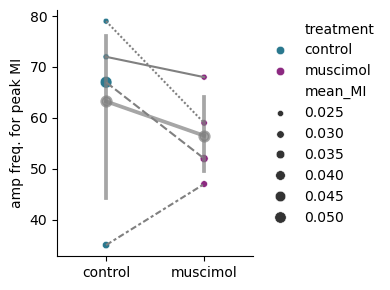

In [78]:

agg_MI_data = subset_MI.groupby(['anim','treatment','ch'], as_index=False).agg(mean_MI = ('MI','mean'),
                                                                                  mean_MI_z = ('MI_z','mean'),
                                                                                mean_amp = ('amp_Hz','mean'),
                                                                                mean_phase = ('phase_Hz','mean'))

fig, ax = plt.subplots(1,1,figsize=(4,3))
measure = 'mean_amp'
sns.scatterplot(agg_MI_data, x="treatment", y=measure, 
                hue="treatment", palette=sns.color_palette(pal),
                size='mean_MI',                
                # legend=['size'],
                ax=ax)
sns.lineplot(agg_MI_data, x="treatment", y=measure, 
                color="gray", 
                style="anim",
                legend=False,
                ax=ax)
sns.pointplot(agg_MI_data, x="treatment", y=measure, 
                color="gray", 
                alpha=0.7,
                # style="anim",
                legend=False,
                ax=ax)
ax.set_xlim(-0.5,1.5)
ax.set_xlabel('')
ax.set_ylabel('amp freq. for peak MI')
ax.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.spines[['right','top']].set_visible(False)
fig.tight_layout()
fig.savefig(r1_dir + '/pac_3_tortMI_Amp_contrast.png', bbox_inches = "tight",
            transparent=True) 



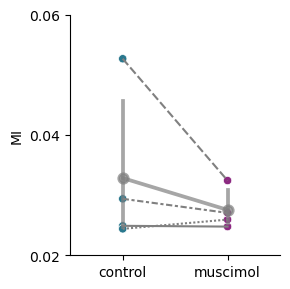

In [65]:

fig, ax = plt.subplots(1,1,figsize=(3,3))
measure = 'mean_MI'
sns.scatterplot(agg_MI_data, x="treatment", y=measure, 
                hue="treatment", palette=sns.color_palette(pal),
                legend=False,
                ax=ax)
sns.lineplot(agg_MI_data, x="treatment", y=measure, 
                color="gray",
                style="anim",
                legend=False,
                ax=ax)
sns.pointplot(agg_MI_data, x="treatment", y=measure, 
                color="gray", 
                alpha=0.7,
                # style="anim",
                legend=False,
                ax=ax)
ax.set_xlim(-0.5,1.5)
ax.set_ylim(0.02,0.06)
ax.set_yticks(np.linspace(0.02,0.06,3))
ax.set_xlabel('')
ax.set_ylabel('MI')
# ax.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.spines[['right','top']].set_visible(False)
fig.tight_layout()
fig.savefig(r1_dir + '/pac_3_tortMI_contrast.png', bbox_inches = "tight", 
            transparent=True) 



In [12]:
analyze_MIs = subset_MI.groupby(['treatment'])['amp_Hz']

print(stats.wilcoxon(analyze_MIs.get_group(('control')), analyze_MIs.get_group(('muscimol'))))
treat_meanstd = [[np.mean(x),np.std(x)] for x in [analyze_MIs.get_group(('control')), analyze_MIs.get_group(('muscimol'))]]
print('control, muscimol:')
print(treat_meanstd)
print('muscimol-control:')
print(treat_meanstd[1][0]-treat_meanstd[0][0])

WilcoxonResult(statistic=65.0, pvalue=0.14290618896484375)
control, muscimol:
[[63.25, 22.708753818736948], [56.5, 21.395092895334667]]
muscimol-control:
-6.75


In [11]:
analyze_MIs = subset_MI.groupby(['treatment'])['MI']

print(stats.wilcoxon(analyze_MIs.get_group(('control')), analyze_MIs.get_group(('muscimol'))))
treat_meanstd = [[np.mean(x),np.std(x)] for x in [analyze_MIs.get_group(('control')), analyze_MIs.get_group(('muscimol'))]]
print('control, muscimol:')
print(treat_meanstd)
print('muscimol-control:')
print(treat_meanstd[1][0]-treat_meanstd[0][0])

WilcoxonResult(statistic=52.0, pvalue=0.04844093322753906)
control, muscimol:
[[0.032829304483231, 0.01173307776105237], [0.02753762040066553, 0.0051120293996333764]]
muscimol-control:
-0.00529168408256547


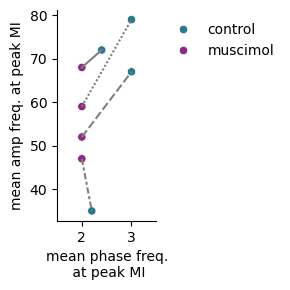

In [74]:

fig, ax = plt.subplots(1,1,figsize=(3,3))
# measure = ''
sns.scatterplot(agg_MI_data, x="mean_phase", y='mean_amp', 
                hue="treatment", palette=sns.color_palette(pal),
                legend=['hue'],
                ax=ax)
sns.lineplot(agg_MI_data, x="mean_phase", y='mean_amp',
                color="gray", 
                style="anim",
                legend=False,
                ax=ax)
ax.set_xlim(1.5,3.5)
ax.set_xlabel('mean phase freq.\n at peak MI')
ax.set_ylabel('mean amp freq. at peak MI')
ax.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.spines[['right','top']].set_visible(False)
fig.tight_layout()
fig.savefig(r1_dir + '/pac_3_tortMI_contrast_phase_amp.png', bbox_inches = "tight", 
            transparent=True) 